Hello All !!

This notebook is a guide to end to end a complete study in machine learning with different concepts like :

* Completing missing values (most important part)
* Exploratory data analysis
* Creating new features (to increase accuracy)
* Encoding features
* Using LightGBM and optimize hyperparameters
* Adding a KNN to LGBM to beat 90% accuracy (voting classifier)

# If you like this notebook, feel free to upvote

In [50]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import plotly.figure_factory as ff
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold, train_test_split
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix, roc_curve,
    precision_recall_curve, accuracy_score, roc_auc_score, f1_score
)
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

import time
from contextlib import contextmanager
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))



In [51]:
data = pd.read_csv('diabetes.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [52]:
data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = data[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)


In [54]:
data.loc[(data['Outcome'] == 0 ) & (data['Insulin'].isnull()), 'Insulin'] = 102.5
data.loc[(data['Outcome'] == 1 ) & (data['Insulin'].isnull()), 'Insulin'] = 169.5
data.loc[(data['Outcome'] == 0 ) & (data['Glucose'].isnull()), 'Glucose'] = 107
data.loc[(data['Outcome'] == 1 ) & (data['Glucose'].isnull()), 'Glucose'] = 140
data.loc[(data['Outcome'] == 0 ) & (data['SkinThickness'].isnull()), 'SkinThickness'] = 27
data.loc[(data['Outcome'] == 1 ) & (data['SkinThickness'].isnull()), 'SkinThickness'] = 32
data.loc[(data['Outcome'] == 0 ) & (data['BloodPressure'].isnull()), 'BloodPressure'] = 70
data.loc[(data['Outcome'] == 1 ) & (data['BloodPressure'].isnull()), 'BloodPressure'] = 74.5
data.loc[(data['Outcome'] == 0 ) & (data['BMI'].isnull()), 'BMI'] = 30.1
data.loc[(data['Outcome'] == 1 ) & (data['BMI'].isnull()), 'BMI'] = 34.3


In [56]:
#Your original, high-performing engineered features
# Body Adiposity Index (overall adiposity)
data['BodyAdiposityIndex'] = data['BMI'] * data['SkinThickness']

# Pregnancy Frequency Index (pregnancy frequency normalized by age)
data['PregnancyFrequency'] = data['Pregnancies'] / (data['Age'] + 1)



# Genetic-Age Risk Score (Interaction of genetic diabetes risk and age)
data['GeneticAgeRisk'] = data['Age'] * data['DiabetesPedigreeFunction']

# Age-Insulin Efficiency (Age relative to insulin levels)
data['AgeInsulinEfficiency'] = data['Age'] / (data['Insulin'] + 1)

# Young and Normoglycemic Status
data['YoungNormoglycemic'] = ((data['Age'] <= 30) & (data['Glucose'] <= 120)).astype(int)

# Healthy BMI Status
data['HealthyBMI'] = (data['BMI'] <= 30).astype(int)

# Low Pregnancy Risk in Youth
data['LowYouthPregnancyRisk'] = ((data['Age'] <= 30) & (data['Pregnancies'] <= 6)).astype(int)

# Optimal Glucose and BP Status
data['OptimalGlucoseBP'] = ((data['Glucose'] <= 105) & (data['BloodPressure'] <= 80)).astype(int)

# Low Subcutaneous Fat
data['LowSkinFat'] = (data['SkinThickness'] <= 20).astype(int)

# Healthy Adiposity Profile
data['HealthyAdiposity'] = ((data['BMI'] < 30) & (data['SkinThickness'] <= 20)).astype(int)

# Optimal Glucose-BMI Profile
data['OptimalMetabolicProfile'] = ((data['Glucose'] <= 105) & (data['BMI'] <= 30)).astype(int)

# Normal Insulin Level Indicator
data['NormalInsulinLevels'] = (data['Insulin'] < 200).astype(int)

# Optimal Blood Pressure Indicator
data['OptimalBloodPressure'] = (data['BloodPressure'] < 80).astype(int)

# Moderate Pregnancy Count
data['ModeratePregnancyCount'] = ((data['Pregnancies'] < 4) & (data['Pregnancies'] != 0)).astype(int)

# Low Adiposity Index Threshold
data['LowAdiposityThreshold'] = (data['BodyAdiposityIndex'] < 1034).astype(int)

# Insulin Resistance Score (Clinically Validated)
data['InsulinResistance'] = (data['Glucose'] * data['Insulin']) / 405

# Diabetes Clinical Risk Score
data['DiabetesRiskScore'] = (
        (data['Glucose'] > 125).astype(int) +
        (data['BMI'] > 30).astype(int) +
        (data['Age'] > 40).astype(int) +
        (data['BloodPressure'] > 80).astype(int) +
        (data['DiabetesPedigreeFunction'] > 0.5).astype(int)
)

# BMI-Insulin Interaction
data['BMIInsulinInteraction'] = data['BMI'] * data['Insulin']

# Metabolic Stress Index
data['MetabolicStressIndex'] = data['Glucose'] / (data['BMI'] + 1)

# Age-Glucose Interaction
data['AgeGlucoseInteraction'] = data['Age'] * data['Glucose']





In [57]:
target_col = ["Outcome"]
cat_cols   = data.nunique()[data.nunique() < 12].keys().tolist()
cat_cols   = [x for x in cat_cols]
num_cols   = [x for x in data.columns if x not in cat_cols + target_col]
bin_cols   = data.nunique()[data.nunique() == 2].keys().tolist()
multi_cols = [i for i in cat_cols if i not in bin_cols]

le = LabelEncoder()
for i in bin_cols :
    data[i] = le.fit_transform(data[i])

data = pd.get_dummies(data = data,columns = multi_cols)

std = StandardScaler()
scaled = std.fit_transform(data[num_cols])
scaled = pd.DataFrame(scaled,columns=num_cols)

data = data.drop(columns = num_cols,axis = 1)
data = data.merge(scaled,left_index=True,right_index=True,how = "left")


In [58]:
data.head()

,Outcome,YoungNormoglycemic,HealthyBMI,LowYouthPregnancyRisk,OptimalGlucoseBP,LowSkinFat,HealthyAdiposity,OptimalMetabolicProfile,NormalInsulinLevels,OptimalBloodPressure,...,DiabetesPedigreeFunction,Age,BodyAdiposityIndex,PregnancyFrequency,GeneticAgeRisk,AgeInsulinEfficiency,InsulinResistance,BMIInsulinInteraction,MetabolicStressIndex,AgeGlucoseInteraction
0,1,0,0,0,0,0,0,0,1,1,...,0.468492,1.425995,0.436284,0.159058,1.202461,-0.013696,0.406797,0.271353,0.505261,1.566179
1,0,0,1,0,1,0,0,1,1,1,...,-0.365061,-0.190672,-0.455696,-0.926872,-0.382029,0.019511,-0.616438,-0.575298,-0.633899,-0.723648
2,1,0,1,0,0,0,0,0,1,1,...,0.604397,-0.105584,-0.512575,1.727389,0.440289,-0.573551,0.777539,-0.226550,3.599533,0.824208
3,0,1,1,1,1,0,0,1,1,1,...,-0.920763,-1.041549,-0.731491,-0.748334,-0.952845,-0.396591,-0.638092,-0.599567,-0.654148,-1.091750
4,1,0,0,0,0,0,0,0,1,1,...,5.484909,-0.020496,1.169312,-1.319655,4.620388,-0.533338,0.277436,0.712147,-0.608347,0.182672


In [59]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']


In [60]:
model = LogisticRegression(max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred = cross_val_predict(model, X, y, cv=cv)
y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:,1]


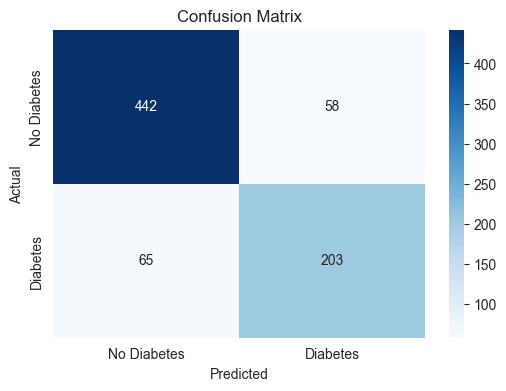

In [61]:
conf_matrix = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


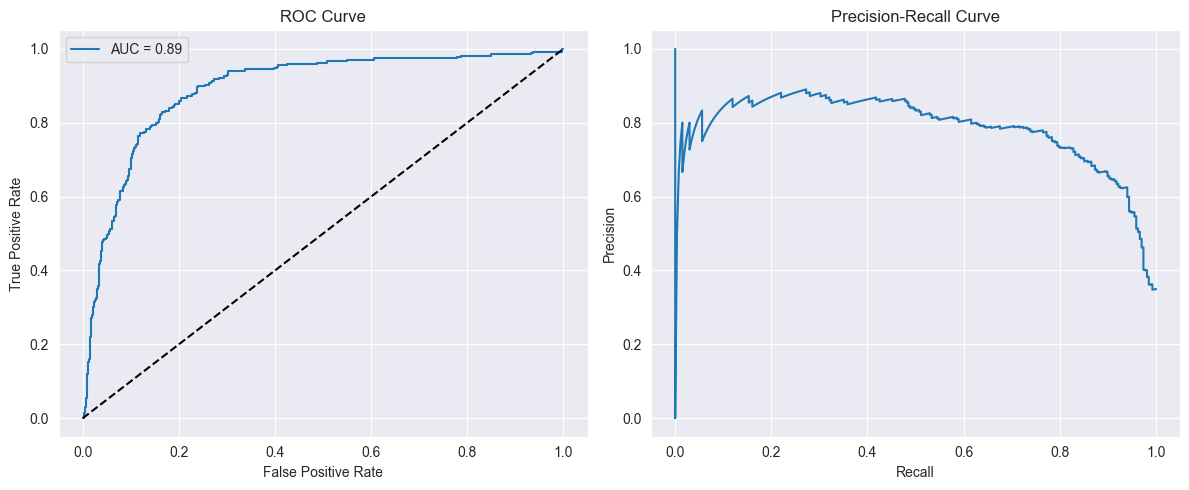

In [62]:
fpr, tpr, _ = roc_curve(y, y_proba)
precision, recall, _ = precision_recall_curve(y, y_proba)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y, y_proba):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()


In [63]:
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc = roc_auc_score(y, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc:.4f}")


Accuracy: 0.8398
Precision: 0.7778
Recall: 0.7575
F1 Score: 0.7675
ROC AUC: 0.8916
